Import the libraries

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

Load the dataset

In [12]:
df = pd.read_csv("Movies_Reviews_modified_version1.csv")

print("Dataset shape:", df.shape)

Dataset shape: (46173, 8)


Check the class distribution

In [13]:
class_counts = df["emotion"].value_counts()

print(class_counts)

emotion
sadness         17339
joy              7861
anticipation     7336
optimism         4812
anger            3638
fear             3460
disgust          1670
surprise           57
Name: count, dtype: int64


Plot the class distribution

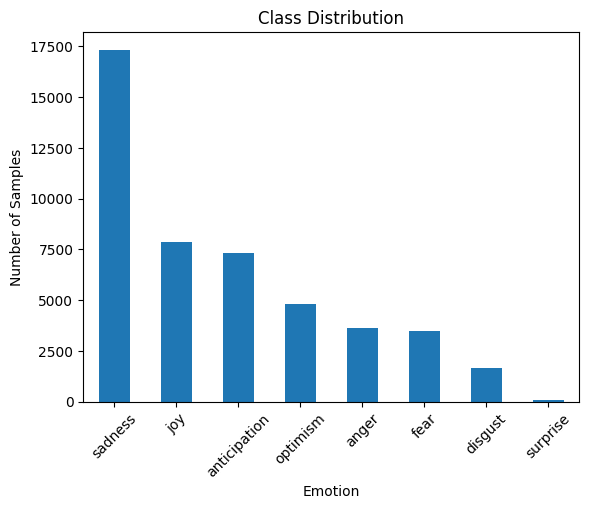

In [14]:
class_counts.plot(kind="bar")

plt.title("Class Distribution")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)

plt.show()

Calculate the imbalance ratio

In [16]:
majority_count = class_counts.max()
minority_count = class_counts.min()

imbalance_ratio = majority_count / minority_count

print("Majority class count:", majority_count)
print("Minority class count:", minority_count)
print("Imbalance ratio:", imbalance_ratio)

Majority class count: 17339
Minority class count: 57
Imbalance ratio: 304.1929824561403


Calculate cost-sensitive class weights

In [17]:
total_samples = len(df)
num_classes = len(class_counts)

class_weights = {}

for class_name, count in class_counts.items():
    class_weights[class_name] = total_samples / (num_classes * count)

print("Class weights:")
for class_name, weight in class_weights.items():
    print(class_name, ":", weight)

Class weights:
sadness : 0.3328695426495184
joy : 0.734210024169953
anticipation : 0.7867536804798255
optimism : 1.1994233167082293
anger : 1.586482957669049
fear : 1.668099710982659
disgust : 3.456062874251497
surprise : 101.25657894736842


Create the inverse penalty weights chart

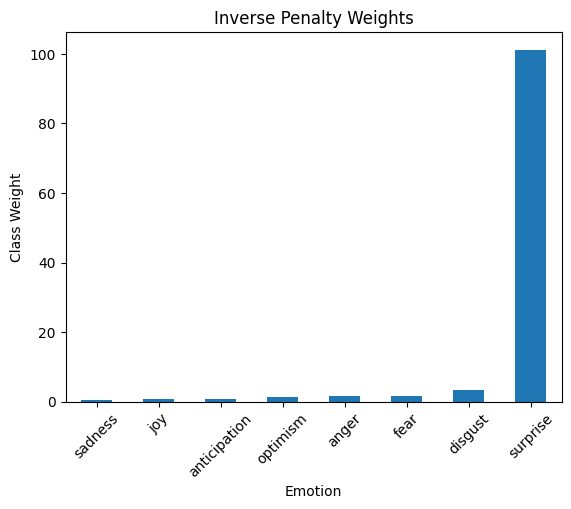

In [18]:
weights = pd.Series(class_weights)

weights.plot(kind="bar")

plt.title("Inverse Penalty Weights")
plt.xlabel("Emotion")
plt.ylabel("Class Weight")
plt.xticks(rotation=45)

plt.show()

Encode the labels

In [19]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["label"] = label_encoder.fit_transform(df["emotion"])

print(df[["emotion", "label"]].head())

        emotion  label
0  anticipation      1
1  anticipation      1
2  anticipation      1
3  anticipation      1
4  anticipation      1


Stratified train-test split

In [20]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Training samples:", len(train_df))
print("Testing samples:", len(test_df))

Training samples: 36938
Testing samples: 9235


Stratified K-Fold

In [21]:
from sklearn.model_selection import StratifiedKFold

X = df.drop(columns=["emotion", "label"])
y = df["label"]

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

for fold, (train_index, validation_index) in enumerate(skf.split(X, y), 1):
    print("Fold:", fold)
    print("Training samples:", len(train_index))
    print("Validation samples:", len(validation_index))

Fold: 1
Training samples: 36938
Validation samples: 9235
Fold: 2
Training samples: 36938
Validation samples: 9235
Fold: 3
Training samples: 36938
Validation samples: 9235
Fold: 4
Training samples: 36939
Validation samples: 9234
Fold: 5
Training samples: 36939
Validation samples: 9234
